In [1]:
print("Hello World")

Hello World


In [34]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from typing import TypedDict, Annotated

load_dotenv()

True

In [31]:
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.6)

In [32]:
llm.invoke("what is ml")

AIMessage(content="**Machine Learning (ML)**\n\nMachine Learning (ML) is a subset of Artificial Intelligence (AI) that involves training algorithms to learn from data and make predictions or decisions without being explicitly programmed.\n\n**Key Characteristics:**\n\n1. **Data-driven**: ML relies on large amounts of data to learn patterns and relationships.\n2. **Algorithmic**: ML uses algorithms to analyze data and make predictions or decisions.\n3. **Self-improvement**: ML models can improve their performance over time as they receive more data and feedback.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**: The model is trained on labeled data to learn the relationship between input and output.\n2. **Unsupervised Learning**: The model is trained on unlabeled data to discover patterns and relationships.\n3. **Reinforcement Learning**: The model learns by interacting with an environment and receiving rewards or penalties.\n\n**Applications of Machine Learning:**\n\n1. *

In [11]:
loader = PyPDFLoader(file_path="intro-to-ml.pdf")
docs = loader.load()

In [12]:
len(docs)

234

In [13]:
docs[0]

Document(metadata={'producer': 'pdfTeX-1.40.10', 'creator': 'LaTeX with hyperref package', 'creationdate': '2010-10-01T15:47:05-07:00', 'author': 'AlexJ.SmolaandVishyS.V.N.Vishwanathan', 'title': 'AnIntroductiontoMachineLearning', 'subject': '', 'keywords': '', 'moddate': '2010-10-01T15:47:05-07:00', 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-1.40.10-2.2 (TeX Live/MacPorts 2009_6) kpathsea version 5.0.0', 'source': 'intro-to-ml.pdf', 'total_pages': 234, 'page': 0, 'page_label': 'i'}, page_content='INTRODUCTION TO MACHINE LEARNING')

In [20]:
docs[2].page_content

'Introduction to Machine Learning\nAlex Smola and S.V.N. Vishwanathan\nYahoo! Labs\nSanta Clara\n–and–\nDepartments of Statistics and Computer Science\nPurdue University\n–and–\nCollege of Engineering and Computer Science\nAustralian National University'

In [14]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = splitter.split_documents(docs)

In [15]:
len(chunks)

560

In [25]:
chunks[2].page_content

'published by the press syndicate of the university of cambridge\nThe Pitt Building, Trumpington Street, Cambridge, United Kingdom\ncambridge university press\nThe Edinburgh Building, Cambridge CB2 2RU, UK\n40 West 20th Street, New York, NY 10011–4211, USA\n477 Williamstown Road, Port Melbourne, VIC 3207, Australia\nRuiz de Alarc´ on 13, 28014 Madrid, Spain\nDock House, The Waterfront, Cape Town 8001, South Africa\nhttp://www.cambridge.org\nc⃝Cambridge University Press 2008\nThis book is in copyright. Subject to statutory exception\nand to the provisions of relevant collective licensing agreements,\nno reproduction of any part may take place without\nthe written permission of Cambridge University Press.\nFirst published 2008\nPrinted in the United Kingdom at the University Press, Cambridge\nTypeface Monotype Times 10/13pt System LATEX 2ε [Alexander J. Smola and S.V.N.\nVishwanathan]\nA catalogue record for this book is available from the British Library'

In [26]:
embedding = HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks, embedding)

In [27]:
vectorstore

In [28]:
retriever = vectorstore.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [29]:
retriever.invoke("what is machine learning")

[Document(id='e4bde592-a81c-4b21-a86e-3a0517a553c1', metadata={'producer': 'pdfTeX-1.40.10', 'creator': 'LaTeX with hyperref package', 'creationdate': '2010-10-01T15:47:05-07:00', 'author': 'AlexJ.SmolaandVishyS.V.N.Vishwanathan', 'title': 'AnIntroductiontoMachineLearning', 'subject': '', 'keywords': '', 'moddate': '2010-10-01T15:47:05-07:00', 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-1.40.10-2.2 (TeX Live/MacPorts 2009_6) kpathsea version 5.0.0', 'source': 'intro-to-ml.pdf', 'total_pages': 234, 'page': 11, 'page_label': '4'}, page_content='4 1 Introduction\nWeb  Images  Maps  News  Shopping  Gmail  more !\n \n    \nSponsored Links\nMachine Learning\nGoogle Sydney needs machine\nlearning experts. Apply today!\nwww.google.com.au/jobs\nSign in\n \n Search   Advanced Search\n  Preferences\n Web    Scholar   Results 1 - 10 of about 10,500,000 for machine learning. (0.06 seconds) \nMachine learning - Wikipedia, the free encyclopedia\nAs a broad subfield of a

In [30]:
@tool
def rag_tool(query: str) -> dict:
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query": query,
        "context": context,
        "metadata": metadata
    }

In [33]:
tools = [rag_tool]
llm_with_tool = llm.bind_tools(tools)

In [46]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [47]:
def chat_node(state: ChatState):
    messages = state["messages"]
    response = llm_with_tool.invoke(messages)
    return {"messages": [response]}

In [48]:
tool_node = ToolNode(tools) 

In [49]:
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")

workflow = graph.compile()

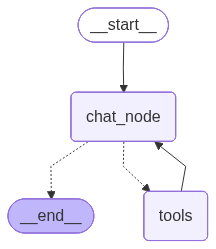

In [50]:
workflow

In [51]:
result = workflow.invoke(
    {
        "messages": [HumanMessage(content="Using the pdf notes, explain how to find the ideal value of K in KNN")]
    }
)

In [56]:
print(result['messages'][-1].content)

The ideal value of K in KNN can be found using various methods, including:

1. Cross-validation: This involves splitting the data into training and testing sets, and then using the training set to find the optimal value of K.
2. Silverman's rule of thumb: This involves choosing the value of K that minimizes the average distance between the K nearest neighbors of a point.
3. Information criteria: This involves using metrics such as the Akaike information criterion (AIC) or the Bayesian information criterion (BIC) to evaluate the goodness of fit of the model for different values of K.

It's worth noting that the choice of K can have a significant impact on the performance of the KNN algorithm, and that different values of K may be optimal for different datasets and problems. Therefore, it's often a good idea to try out multiple values of K and evaluate their performance using a validation set.
